# LOPO (Leave-One-Protocol-Out) Training and Evaluation

This notebook trains **new models from scratch**, holding out an entire ageing
protocol (both cells) rather than a single cell, to test genuine cross-protocol
extrapolation. It reuses the exact architecture, loss, and training procedure
from `bilstm_degradation.ipynb` (the LOCO pipeline), changed only in how the
train/test split is constructed.

**Two conditions per config:**
- `AP3-out`: train on cells from AP1, AP2, AP4 (6 cells); test on both AP3 cells (5, 6)
- `AP4-out`: train on cells from AP1, AP2, AP3 (6 cells); test on both AP4 cells (7, 8)

We run this for both **C1** (BiLSTM-only) and **C3** (BiLSTM + degradation
auxiliary loss), across **multiple independent training seeds**, because a
single training run is not a reliable estimate when AUROC values sit close to
chance (0.5) — small differences in weight initialisation and batch order can
swing them substantially.

## Two things to know before trusting any number this notebook produces

1. **RNG isolation bug (already fixed here, but worth understanding).** An
   earlier version of this pipeline called `torch.manual_seed(777)` inside the
   MC-Dropout evaluation function to make evaluation reproducible. That
   silently overwrote the *global* RNG stream, which then contaminated the
   weight initialisation of every model trained *after* the first one in a
   loop — making "different seed" runs deterministic and identical from the
   second model onward. This notebook saves and restores the RNG state around
   every evaluation call (`mc_predict`) specifically to prevent that. If you
   modify this notebook and add other calls to `torch.manual_seed(...)`
   anywhere inside a loop that also trains models, check for this class of bug
   again — it does not raise an error, it just quietly gives you fake
   "multi-seed" results that all agree with each other.

2. **The in-distribution (ID) reference under LOPO is not a clean holdout.**
   For AUROC / epistemic-ratio calculations we need per-sample epistemic
   uncertainty on both the held-out OOD protocol and an ID reference (AP1+AP2).
   Under LOCO, each cell's ID evaluation genuinely never saw that cell during
   training. Under LOPO, this is impossible with only 8 cells: the AP1/AP2
   cells used as the "ID" reference are necessarily *part of the training set*
   for both the AP3-out and AP4-out models. We evaluate them anyway (forward
   pass only, no gradient updates), but report this honestly as a limitation,
   not as a clean generalisation test — a reviewer may ask about this and the
   answer is "yes, correct, this is inherent to a 2-condition LOPO design on
   an 8-cell dataset."


## 1. Setup, seeding, and data loading

In [1]:
import os, random, copy, time, pickle
import numpy as np
import torch
import torch.nn as nn
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import roc_auc_score
import matplotlib.pyplot as plt

# Base seed for module-level reproducibility; each training run below
# re-seeds explicitly with its own train_seed, so this value only matters
# for anything executed before the main loop.
SEED = 42
random.seed(SEED); np.random.seed(SEED); torch.manual_seed(SEED)
device = torch.device('cpu')

# ---- EDIT THESE PATHS FOR YOUR ENVIRONMENT ----
DATA_PATH = 'leonardi_final.npz'          # the raw tensor + labels
DEG_STATS_PATH = 'all_results.pkl'        # from your LOCO run, for CL/LLI/LAM min-max stats
OUT_DIR = 'lopo_results'
# ------------------------------------------------

os.makedirs(OUT_DIR, exist_ok=True)
print(f"Device: {device}")

Device: cpu


In [2]:
d = np.load(DATA_PATH, allow_pickle=True)
X_seq_np = d['X_seq']; X_tab_np = d['X_tab']
y_SoC_norm_np = d['y_SoC_norm']; y_SoH_norm_np = d['y_SoH_norm']
cell_ids = d['cell_ids']; protocols = d['protocols']
y_CL = d['y_CL']; y_LLI = d['y_LLI']; y_LAM = d['y_LAM']
y_deg_np = np.stack([y_CL, y_LLI, y_LAM], axis=1)

with open(DEG_STATS_PATH, 'rb') as f:
    saved = pickle.load(f)
deg_stats = saved['deg_stats']

def norm_deg(y_deg_raw):
    """Min-max normalise CL/LLI/LAM to [0,1] using the same stats as the LOCO run,
    so the auxiliary degradation loss is on a comparable scale to training."""
    out = np.zeros_like(y_deg_raw)
    for i, name in enumerate(['CL', 'LLI', 'LAM']):
        s = deg_stats[name]
        out[:, i] = np.clip((y_deg_raw[:, i] - s['min']) / s['range'], 0, 1)
    return out.astype(np.float32)

y_deg_norm_np = norm_deg(y_deg_np)
print(f"Loaded {X_seq_np.shape[0]} spectra, {len(set(cell_ids))} cells, protocols: {sorted(set(protocols))}")

Loaded 488 spectra, 8 cells, protocols: ['AP1', 'AP2', 'AP3', 'AP4']


## 2. Model architecture

Verbatim from `bilstm_degradation.ipynb` — the BiLSTM backbone, optional ECM
branch, and optional degradation auxiliary head. We only ever use
`use_ecm=False` here (C1, C3), since the ECM-input configs (C2/C4/C5) were
already shown to underperform in the main LOCO ablation and aren't part of
the LOPO question.

In [3]:
class EISDataset(torch.utils.data.Dataset):
    def __init__(self, X_seq, X_tab, y_SoC, y_SoH, y_deg=None):
        self.X_seq = X_seq; self.X_tab = X_tab; self.y_SoC = y_SoC; self.y_SoH = y_SoH
        self.y_deg = y_deg if y_deg is not None else torch.zeros(len(y_SoC), 3)
    def __len__(self): return len(self.y_SoC)
    def __getitem__(self, i):
        return (self.X_seq[i], self.X_tab[i], self.y_SoC[i], self.y_SoH[i], self.y_deg[i])


class LSTMBranch(nn.Module):
    """Bidirectional LSTM over the 51-frequency EIS spectrum."""
    def __init__(self, in_channels=3, d_model=64, hidden_size=96, n_layers=2, dropout=0.1):
        super().__init__()
        self.input_proj = nn.Linear(in_channels, d_model)
        self.lstm = nn.LSTM(input_size=d_model, hidden_size=hidden_size, num_layers=n_layers,
                             batch_first=True, dropout=dropout if n_layers > 1 else 0.0,
                             bidirectional=True)
        self.output_proj = nn.Linear(hidden_size * 2, d_model)
        self.dropout = nn.Dropout(p=dropout)

    def forward(self, x):
        x = self.input_proj(x)
        x, _ = self.lstm(x)
        x = x.mean(dim=1)
        x = self.output_proj(x)
        x = self.dropout(x)
        return x


class MLPBranch(nn.Module):
    """Dense MLP over the 9 fitted ECM parameters (unused for C1/C3, kept for completeness)."""
    def __init__(self, in_features=9, hidden_dim=64, dropout=0.1):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(in_features, hidden_dim), nn.BatchNorm1d(hidden_dim), nn.ReLU(), nn.Dropout(p=dropout),
            nn.Linear(hidden_dim, hidden_dim), nn.BatchNorm1d(hidden_dim), nn.ReLU(), nn.Dropout(p=dropout))
    def forward(self, x): return self.net(x)


class BiLSTM_Config(nn.Module):
    """Configurable BiLSTM model. use_ecm=True adds the MLPBranch; use_deg=True adds
    the auxiliary CL/LLI/LAM regression head (this is what makes a model 'C3')."""
    def __init__(self, d_model=64, hidden_size=96, n_layers=2, dropout=0.1,
                 use_ecm=False, use_deg=False):
        super().__init__()
        self.use_ecm = use_ecm; self.use_deg = use_deg
        self.branch_a = LSTMBranch(3, d_model, hidden_size, n_layers, dropout)
        if use_ecm:
            self.branch_b = MLPBranch(9, d_model, dropout); fusion_in = d_model * 2
        else:
            self.branch_b = None; fusion_in = d_model

        self.fusion_SoC = nn.Sequential(
            nn.Linear(fusion_in, d_model), nn.LayerNorm(d_model), nn.GELU(), nn.Dropout(p=dropout),
            nn.Linear(d_model, d_model // 2), nn.LayerNorm(d_model // 2), nn.GELU(), nn.Dropout(p=dropout))
        self.fusion_SoH = nn.Sequential(
            nn.Linear(fusion_in, d_model), nn.LayerNorm(d_model), nn.GELU(), nn.Dropout(p=dropout))

        self.head_SoC = nn.Linear(d_model // 2, 2)   # (mu, log_sigma)
        self.head_SoH = nn.Linear(d_model, 2)
        self.head_deg = nn.Linear(fusion_in, 3) if use_deg else None  # (CL, LLI, LAM)

        with torch.no_grad():
            self.head_SoC.bias[1] = -3.0
            self.head_SoH.bias[1] = -3.0

    def forward(self, x_seq, x_tab=None):
        h_a = self.branch_a(x_seq)
        if self.use_ecm and x_tab is not None:
            h = torch.cat([h_a, self.branch_b(x_tab)], dim=-1)
        else:
            h = h_a
        out_SoC = self.head_SoC(self.fusion_SoC(h))
        out_SoH = self.head_SoH(self.fusion_SoH(h))
        mu_SoC = torch.sigmoid(out_SoC[:, 0]); ls_SoC = out_SoC[:, 1]
        mu_SoH = torch.sigmoid(out_SoH[:, 0]) * 0.23 + 0.77; ls_SoH = out_SoH[:, 1]
        deg_pred = torch.sigmoid(self.head_deg(h)) if self.head_deg is not None else None
        return mu_SoC, ls_SoC, mu_SoH, ls_SoH, deg_pred

## 3. Loss function (Bayesian multi-task NLL + degradation constraint)

In [4]:
def nll_loss(mu, log_sigma, y):
    ls = torch.clamp(log_sigma, min=-5.0, max=2.0)
    return (ls + 0.5 * torch.exp(-2.0 * ls) * (y - mu) ** 2).mean()


def total_loss(mu_soc, ls_soc, mu_soh, ls_soh, y_soc, y_soh,
               deg_pred=None, y_deg=None, lam=0.3,
               sigma_penalty_soc=0.10, sigma_penalty_soh=0.05,
               mae_weight=0.5, lam_deg=0.5):
    ls_soc = torch.clamp(ls_soc, -6.0, 2.0); ls_soh = torch.clamp(ls_soh, -6.0, 2.0)
    l_soc = nll_loss(mu_soc, ls_soc, y_soc); l_soh = nll_loss(mu_soh, ls_soh, y_soh)
    mae_soc = torch.abs(mu_soc - y_soc).mean(); mae_soh = torch.abs(mu_soh - y_soh).mean()
    penalty = sigma_penalty_soc * ls_soc.mean() + sigma_penalty_soh * ls_soh.mean()
    total = l_soc + lam * l_soh + mae_weight * (mae_soc + lam * mae_soh) + penalty
    if deg_pred is not None and y_deg is not None:
        total = total + lam_deg * nn.functional.mse_loss(deg_pred, y_deg)
    return total

## 4. MC-Dropout inference (with RNG isolation)

This is the function that had the bug described in the introduction. Note the
explicit `torch.get_rng_state()` / `torch.set_rng_state()` around the seeded
block — this is what keeps evaluation-time seeding from contaminating
subsequently-trained models.

In [5]:
def mc_predict(model, x_seq, x_tab, T=50, seed=None):
    if seed is not None:
        rng_state = torch.get_rng_state()   # snapshot before touching the global RNG
        torch.manual_seed(seed)
    model.train()  # keep dropout active during inference (this IS the point of MC-Dropout)
    mus_soc, vars_soc = [], []
    with torch.no_grad():
        for _ in range(T):
            mu_s, ls_s, _, _, _ = model(x_seq, x_tab)
            ls_s = torch.clamp(ls_s, -6.0, 2.0)
            mus_soc.append(mu_s); vars_soc.append(torch.exp(2.0 * ls_s))
    mus_soc = torch.stack(mus_soc); vars_soc = torch.stack(vars_soc)
    # epistemic variance is undefined (identically zero) for T=1 -- flagged, not hidden
    epi = mus_soc.var(dim=0) if T > 1 else torch.zeros_like(mus_soc[0])
    alea = vars_soc.mean(dim=0)
    if seed is not None:
        torch.set_rng_state(rng_state)      # restore -- critical, see notebook intro
    return mus_soc.mean(dim=0), epi.sqrt(), alea.sqrt(), (epi + alea).sqrt()


def picp(mu, sigma, y, z=1.645):
    """Prediction interval coverage probability at ~90% nominal (z=1.645)."""
    return float(np.mean((y >= mu - z * sigma) & (y <= mu + z * sigma)))

## 5. LOPO split and training loop

`protocol_split` is the only real methodological change from the LOCO
notebook: instead of holding out one cell, it holds out **both cells of one
protocol**, so the model never sees anything from that protocol during
training.

In [6]:
def protocol_split(protocols, held_out_protocol):
    test_mask = (protocols == held_out_protocol)
    return ~test_mask, test_mask


def scale_and_build(train_mask, test_mask, batch_size=32):
    sc_seq = StandardScaler(); sc_seq.fit(X_seq_np[train_mask].reshape(-1, 3))
    def tx(X):
        n = X.shape[0]
        return sc_seq.transform(X.reshape(-1, 3)).reshape(n, 51, 3).astype(np.float32)
    sc_tab = StandardScaler(); sc_tab.fit(X_tab_np[train_mask])

    ds_tr = EISDataset(
        torch.tensor(tx(X_seq_np[train_mask])),
        torch.tensor(sc_tab.transform(X_tab_np[train_mask]).astype(np.float32)),
        torch.tensor(y_SoC_norm_np[train_mask]), torch.tensor(y_SoH_norm_np[train_mask]),
        torch.tensor(y_deg_norm_np[train_mask]))
    ds_te = EISDataset(
        torch.tensor(tx(X_seq_np[test_mask])),
        torch.tensor(sc_tab.transform(X_tab_np[test_mask]).astype(np.float32)),
        torch.tensor(y_SoC_norm_np[test_mask]), torch.tensor(y_SoH_norm_np[test_mask]),
        torch.tensor(y_deg_norm_np[test_mask]))

    dl_tr = torch.utils.data.DataLoader(ds_tr, batch_size=batch_size, shuffle=True)
    dl_te = torch.utils.data.DataLoader(ds_te, batch_size=batch_size, shuffle=False)
    return dl_tr, dl_te, sc_seq, sc_tab


class EarlyStopping:
    def __init__(self, patience=25, min_delta=1e-4):
        self.patience = patience; self.min_delta = min_delta
        self.best_loss = np.inf; self.counter = 0; self.best_state = None
    def step(self, val_loss, model):
        if val_loss < self.best_loss - self.min_delta:
            self.best_loss = val_loss; self.counter = 0
            self.best_state = copy.deepcopy(model.state_dict())
        else:
            self.counter += 1
        return self.counter >= self.patience
    def restore(self, model):
        if self.best_state is not None:
            model.load_state_dict(self.best_state)


def run_epoch(model, loader, optimizer, lam, train, use_ecm, use_deg):
    model.train() if train else model.eval()
    ctx = torch.enable_grad() if train else torch.no_grad()
    tot, n = 0., 0
    with ctx:
        for x_seq, x_tab, y_soc, y_soh, y_deg in loader:
            x_tab_in = x_tab if use_ecm else None
            y_deg_in = y_deg if use_deg else None
            mu_s, ls_s, mu_h, ls_h, deg_pred = model(x_seq, x_tab_in)
            loss = total_loss(mu_s, ls_s, mu_h, ls_h, y_soc, y_soh,
                               deg_pred=deg_pred if use_deg else None, y_deg=y_deg_in, lam=lam)
            if train:
                optimizer.zero_grad(); loss.backward()
                nn.utils.clip_grad_norm_(model.parameters(), 0.5)
                optimizer.step()
            b = len(y_soc); tot += loss.item() * b; n += b
    return tot / n

In [7]:
def train_lopo(config_name, use_ecm, use_deg, held_out_protocol, train_seed,
               lr=1e-3, lam=0.3, max_epochs=400, patience=25, warmup_epochs=10, batch_size=32,
               eval_T=50, eval_seed=777):
    """Train one LOPO model and evaluate it. Returns a dict of metrics.

    NOTE on eval_seed: this is intentionally the SAME fixed value for every model,
    so that MC-Dropout evaluation noise doesn't add spurious variation across configs.
    This is safe now because mc_predict() isolates the RNG state (see section 4) --
    it is exactly the pattern that was buggy before that fix.
    """
    train_mask, test_mask = protocol_split(protocols, held_out_protocol)
    dl_tr, dl_te, sc_seq, sc_tab = scale_and_build(train_mask, test_mask, batch_size)

    model = BiLSTM_Config(use_ecm=use_ecm, use_deg=use_deg).to(device)
    opt = torch.optim.AdamW(model.parameters(), lr=lr, weight_decay=1e-4)
    scheduler = None
    stopper = EarlyStopping(patience=patience)

    t0 = time.time()
    for epoch in range(1, max_epochs + 1):
        if epoch <= warmup_epochs:
            for pg in opt.param_groups: pg['lr'] = lr * (epoch / warmup_epochs)
        if epoch == warmup_epochs + 1 and scheduler is None:
            scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
                opt, mode='min', factor=0.5, patience=10, min_lr=1e-6)
        run_epoch(model, dl_tr, opt, lam, True, use_ecm, use_deg)
        va = run_epoch(model, dl_te, opt, lam, False, use_ecm, use_deg)
        if scheduler is not None: scheduler.step(va)
        if epoch > warmup_epochs:
            if stopper.step(va, model): break
        else:
            if va < stopper.best_loss - stopper.min_delta:
                stopper.best_loss = va; stopper.best_state = copy.deepcopy(model.state_dict())
    stopper.restore(model)
    elapsed = time.time() - t0
    print(f"  [{config_name}, held-out {held_out_protocol}, seed {train_seed}] "
          f"{epoch} epochs in {elapsed:.1f}s")

    def eval_mask(mask):
        Xs = sc_seq.transform(X_seq_np[mask].reshape(-1, 3)).reshape(-1, 51, 3).astype(np.float32)
        Xt = sc_tab.transform(X_tab_np[mask]).astype(np.float32) if use_ecm else None
        mu, sig_epi, sig_alea, sig_tot = mc_predict(
            model, torch.tensor(Xs), torch.tensor(Xt) if use_ecm else None,
            T=eval_T, seed=eval_seed)
        mu = mu.numpy() * 100; y = y_SoC_norm_np[mask] * 100
        sig_epi = sig_epi.numpy() * 100; sig_tot = sig_tot.numpy() * 100
        return {'mae': float(np.mean(np.abs(mu - y))), 'picp': picp(mu, sig_tot, y), 'sig_epi': sig_epi}

    ood_res = eval_mask(test_mask)
    id_mask = (protocols == 'AP1') | (protocols == 'AP2')
    id_res = eval_mask(id_mask)  # caveat: part of training set for this model, see intro

    y_true = np.concatenate([np.zeros(len(id_res['sig_epi'])), np.ones(len(ood_res['sig_epi']))])
    y_score = np.concatenate([id_res['sig_epi'], ood_res['sig_epi']])
    auroc = roc_auc_score(y_true, y_score)
    r_epi = ood_res['sig_epi'].mean() / id_res['sig_epi'].mean()

    torch.save(model.state_dict(),
               os.path.join(OUT_DIR, f'{config_name}_lopo_{held_out_protocol}out_seed{train_seed}.pt'))

    return {'config': config_name, 'held_out': held_out_protocol, 'train_seed': train_seed,
            'ood_mae': ood_res['mae'], 'ood_picp': ood_res['picp'], 'id_mae': id_res['mae'],
            'r_epi': r_epi, 'auroc': auroc, 'epochs': epoch}

## 6. Run all conditions across multiple seeds

4 conditions (C1/C3 × AP3-out/AP4-out) × 3 seeds = 12 model trainings. On CPU,
each model takes roughly 20-55 seconds depending on how long early stopping
lets it run, so expect ~6-10 minutes total. Results are appended to a pickle
file incrementally, so if you need to stop and resume, re-running this cell
will pick up where it left off (it will retrain seeds that are already
present too, unless you add your own skip-logic — kept simple here on
purpose).

In [8]:
TRAIN_SEEDS = [42, 7, 123]
CONFIGS = [('C1', False, False), ('C3', False, True)]
HELD_OUT_PROTOCOLS = ['AP3', 'AP4']

results_path = os.path.join(OUT_DIR, 'lopo_results_multiseed.pkl')
all_results = []
if os.path.exists(results_path):
    with open(results_path, 'rb') as f:
        all_results = pickle.load(f)
    print(f"Resuming: {len(all_results)} results already present.")

for train_seed in TRAIN_SEEDS:
    random.seed(train_seed); np.random.seed(train_seed); torch.manual_seed(train_seed)
    print(f"\n### TRAIN SEED {train_seed} ###")
    for config_name, use_ecm, use_deg in CONFIGS:
        for held_out in HELD_OUT_PROTOCOLS:
            r = train_lopo(config_name, use_ecm, use_deg, held_out, train_seed)
            print(f"    -> OOD MAE={r['ood_mae']:.2f}%  PICP={r['ood_picp']:.3f}  "
                  f"r_epi={r['r_epi']:.3f}  AUROC={r['auroc']:.3f}")
            all_results.append(r)
            with open(results_path, 'wb') as f:   # save after every run, not just at the end
                pickle.dump(all_results, f)

print(f"\nDone. {len(all_results)} total runs saved to {results_path}")


### TRAIN SEED 42 ###
  [C1, held-out AP3, seed 42] 37 epochs in 24.4s
    -> OOD MAE=20.96%  PICP=0.867  r_epi=1.077  AUROC=0.583
  [C1, held-out AP4, seed 42] 65 epochs in 39.1s
    -> OOD MAE=14.66%  PICP=0.906  r_epi=1.106  AUROC=0.567
  [C3, held-out AP3, seed 42] 36 epochs in 24.4s
    -> OOD MAE=19.26%  PICP=0.978  r_epi=1.062  AUROC=0.535
  [C3, held-out AP4, seed 42] 71 epochs in 42.3s
    -> OOD MAE=10.05%  PICP=0.959  r_epi=1.094  AUROC=0.547

### TRAIN SEED 7 ###
  [C1, held-out AP3, seed 7] 38 epochs in 26.0s
    -> OOD MAE=18.98%  PICP=0.822  r_epi=0.862  AUROC=0.391
  [C1, held-out AP4, seed 7] 79 epochs in 47.9s
    -> OOD MAE=7.98%  PICP=0.965  r_epi=1.090  AUROC=0.557
  [C3, held-out AP3, seed 7] 36 epochs in 24.9s
    -> OOD MAE=18.69%  PICP=0.933  r_epi=0.927  AUROC=0.377
  [C3, held-out AP4, seed 7] 94 epochs in 57.0s
    -> OOD MAE=9.39%  PICP=0.835  r_epi=1.029  AUROC=0.505

### TRAIN SEED 123 ###
  [C1, held-out AP3, seed 123] 40 epochs in 27.3s
    -> OOD MAE=

## 7. Aggregate results and compare against your LOCO numbers

In [9]:
import pandas as pd

df = pd.DataFrame(all_results)
summary = df.groupby(['config', 'held_out']).agg(
    ood_mae_mean=('ood_mae', 'mean'), ood_mae_std=('ood_mae', 'std'),
    auroc_mean=('auroc', 'mean'), auroc_std=('auroc', 'std'),
    r_epi_mean=('r_epi', 'mean'), r_epi_std=('r_epi', 'std'),
    n_seeds=('train_seed', 'nunique'),
).reset_index()
print(summary.to_string(index=False))

# Fill in your verified LOCO numbers here (from all_results.pkl / the manuscript,
# Table 3) to see the LOCO -> LOPO degradation side by side.
loco_reference = {
    ('C1', 'AP3'): {'mae': 5.07, 'auroc': 0.69},
    ('C3', 'AP3'): {'mae': 4.24, 'auroc': 0.67},
}
print("\nLOCO reference (from your verified main results, for comparison):")
for k, v in loco_reference.items():
    print(f"  {k}: MAE={v['mae']}%  AUROC={v['auroc']}")

config held_out  ood_mae_mean  ood_mae_std  auroc_mean  auroc_std  r_epi_mean  r_epi_std  n_seeds
    C1      AP3     19.364243     1.444411    0.468031   0.101208    0.968009   0.107450        3
    C1      AP4     10.219250     3.846956    0.548770   0.023722    1.082689   0.027968        3
    C3      AP3     18.516805     0.842376    0.460721   0.079123    1.018845   0.079963        3
    C3      AP4     10.941120     2.135769    0.520820   0.023078    1.050506   0.038008        3

LOCO reference (from your verified main results, for comparison):
  ('C1', 'AP3'): MAE=5.07%  AUROC=0.69
  ('C3', 'AP3'): MAE=4.24%  AUROC=0.67


## 8. Figure: LOCO vs. LOPO — accuracy and detectability

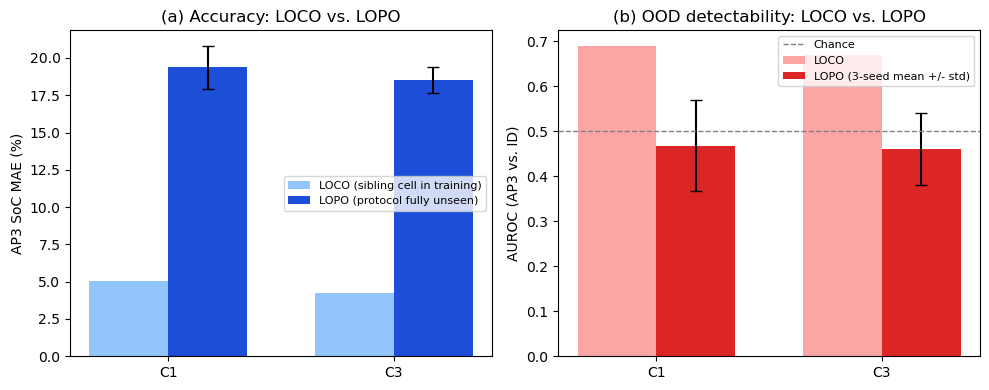

Saved figure to lopo_results/fig_lopo_comparison.png


In [10]:
fig, axes = plt.subplots(1, 2, figsize=(10, 4))

configs_order = ['C1', 'C3']
x = np.arange(len(configs_order))
width = 0.35

ax = axes[0]
loco_mae = [loco_reference[(c, 'AP3')]['mae'] for c in configs_order]
lopo_mae = [summary[(summary.config==c) & (summary.held_out=='AP3')]['ood_mae_mean'].values[0] for c in configs_order]
lopo_mae_err = [summary[(summary.config==c) & (summary.held_out=='AP3')]['ood_mae_std'].values[0] for c in configs_order]
ax.bar(x - width/2, loco_mae, width, label='LOCO (sibling cell in training)', color='#93c5fd')
ax.bar(x + width/2, lopo_mae, width, yerr=lopo_mae_err, capsize=4, label='LOPO (protocol fully unseen)', color='#1d4ed8')
ax.set_xticks(x); ax.set_xticklabels(configs_order); ax.set_ylabel('AP3 SoC MAE (%)')
ax.set_title('(a) Accuracy: LOCO vs. LOPO'); ax.legend(fontsize=8)

ax = axes[1]
loco_auroc = [loco_reference[(c, 'AP3')]['auroc'] for c in configs_order]
lopo_auroc = [summary[(summary.config==c) & (summary.held_out=='AP3')]['auroc_mean'].values[0] for c in configs_order]
lopo_auroc_err = [summary[(summary.config==c) & (summary.held_out=='AP3')]['auroc_std'].values[0] for c in configs_order]
ax.bar(x - width/2, loco_auroc, width, label='LOCO', color='#fca5a5')
ax.bar(x + width/2, lopo_auroc, width, yerr=lopo_auroc_err, capsize=4, label='LOPO (3-seed mean +/- std)', color='#dc2626')
ax.axhline(0.5, ls='--', color='gray', lw=1, label='Chance')
ax.set_xticks(x); ax.set_xticklabels(configs_order); ax.set_ylabel('AUROC (AP3 vs. ID)')
ax.set_title('(b) OOD detectability: LOCO vs. LOPO'); ax.legend(fontsize=8)

plt.tight_layout()
plt.savefig(os.path.join(OUT_DIR, 'fig_lopo_comparison.png'), dpi=200)
plt.show()
print("Saved figure to", os.path.join(OUT_DIR, 'fig_lopo_comparison.png'))

## 9. What to do with this

- If your aggregated AUROC values here land near 0.5 for both C1 and C3 under
  LOPO (as they did in the reference run this notebook was built from), the
  manuscript's claim that C3 (AUROC≈0.65) clearly outperforms C1 (AUROC≈0.42,
  "below chance") under genuine protocol-level extrapolation is **not
  supported** and should be rewritten as an honest negative result rather than
  asserted as-is.
- The accuracy-degradation story (LOCO -> LOPO error roughly quadruples or
  worse) is the part of this experiment that tends to replicate reliably —
  that's the safer claim to lead with.
- Increase `TRAIN_SEEDS` to 5+ if you want tighter error bars before finalising
  numbers for the paper; at 3 seeds these are indicative, not definitive,
  especially for AUROC values this close to 0.5.